## Data research

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data_load import load_nuclear_data

df = load_nuclear_data("../data/raw/nuclear_safety.xlsx")
df['station'] = df['station'].replace('ЮУАЕС', 'ПАЕС')

In [33]:
df.head()

,year,quarter,station,irg,irg_index,iodine_ radionuclides,iodine_ radionuclides_index,stable_radionuclides,stable_ radionuclides_index,cs_137_emission,co_60_ emission,cs_137_dump,co_60_dump,volume,index_radioactive_releas,index_dump
0,2018,1,ЗАЕС,89.0,0.13,260.0,0.0,650.0,0.03,1980.0,1020.0,4330.0,3670.0,833000.0,0.149,0.330
1,2018,1,РАЕС,105.0,0.16,147.0,0.0,269.0,0.07,587.0,165.0,4800.0,620.0,2220000.0,0.780,0.096
2,2018,1,ПАЕС,45.0,0.10,76.0,0.0,116.0,0.02,136.0,373.0,390.0,370.0,14600.0,0.136,0.284
3,2018,1,ХАЕС,31.0,0.07,26.8,0.0,37.5,0.00,29.4,13.8,380.0,NaN,22070.0,0.110,0.030
4,2018,2,ЗАЕС,84.0,0.12,262.0,0.0,640.0,0.03,453.0,1003.0,4627.0,3432.0,812667.0,0.115,0.910


In [43]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["quarter"] = pd.to_numeric(df["quarter"], errors="coerce")

df = df.dropna(subset=["year", "quarter", "station"]).copy()

df["year"] = df["year"].astype(int)
df["quarter"] = df["quarter"].astype(int)

df["period"] = pd.PeriodIndex.from_fields(
    year=df["year"],
    quarter=df["quarter"],
    freq="Q"
)

df = df.sort_values(["station", "period"]).reset_index(drop=True)

df.head()

,year,quarter,station,irg,irg_index,iodine_ radionuclides,iodine_ radionuclides_index,stable_radionuclides,stable_ radionuclides_index,cs_137_emission,co_60_ emission,cs_137_dump,co_60_dump,volume,index_radioactive_releas,index_dump,period
0,2018,1,ЗАЕС,89.0,0.13,260.0,0.0,650.0,0.03,1980.0,1020.0,4330.0,3670.0,833000.0,0.149,0.33,2018Q1
1,2018,2,ЗАЕС,84.0,0.12,262.0,0.0,640.0,0.03,453.0,1003.0,4627.0,3432.0,812667.0,0.115,0.91,2018Q2
2,2018,3,ЗАЕС,84.0,0.12,235.0,0.0,611.0,0.03,876.0,201.0,5890.0,3500.0,874528.0,0.870,1.52,2018Q3
3,2018,4,ЗАЕС,79.0,0.11,240.0,0.0,750.0,0.03,304.0,868.0,3600.0,3100.0,778103.0,0.940,2.14,2018Q4
4,2019,1,ЗАЕС,78.0,0.11,265.0,0.0,697.0,0.03,1652.0,944.0,3608.0,3739.0,702304.0,0.830,0.39,2019Q1


## Гіпотеза №1

Перевіримо Гіпотезу №1: рівень радіації стабільний та не перевищує встановлених нормативних значень.

Для оцінки наявності аномальних перевищень радіаційного фону було проаналізовано індексні показники: irg_index (інертні радіоактивні гази), iodine_radionuclides_index (радіонукліди йоду) та stable_radionuclides_index (довгоіснуючі радіонукліди). Ці індекси відображають частку фактичного рівня викидів від допустимого нормативу.


In [37]:
check_indices = ['irg_index', 'iodine_ radionuclides_index', 'stable_ radionuclides_index']

for col in check_indices:
    anomalies = df[df[col] > 1]
    if not anomalies.empty:
        print(f"Знайдено перевищення у колонці {col}:")
        display(anomalies[['year', 'quarter', 'station', col]])
    else:
        print(f"У колонці {col} аномальних перевищень не виявлено (всі значенні <= 1).")

print("\nСтатистика індексів:")
display(df[check_indices].describe())

У колонці irg_index аномальних перевищень не виявлено (всі значенні <= 1).
У колонці iodine_ radionuclides_index аномальних перевищень не виявлено (всі значенні <= 1).
У колонці stable_ radionuclides_index аномальних перевищень не виявлено (всі значенні <= 1).

Статистика індексів:


,irg_index,iodine_ radionuclides_index,stable_ radionuclides_index
count,115.000000,115.0,115.00000
mean,0.118261,0.0,0.03087
std,0.059150,0.0,0.02674
min,0.050000,0.0,0.00000
25%,0.070000,0.0,0.00000
50%,0.100000,0.0,0.03000
75%,0.150000,0.0,0.06000
max,0.340000,0.0,0.09000


За результатами аналізу встановлено, що в жодному з показників не зафіксовано значень, що перевищують норматив (усі значення <= 1).

Отже, гіпотеза підтверджується: рівень радіаційного фону в зоні розташування АЕС є стабільним і не перевищує встановлених нормативних значень.

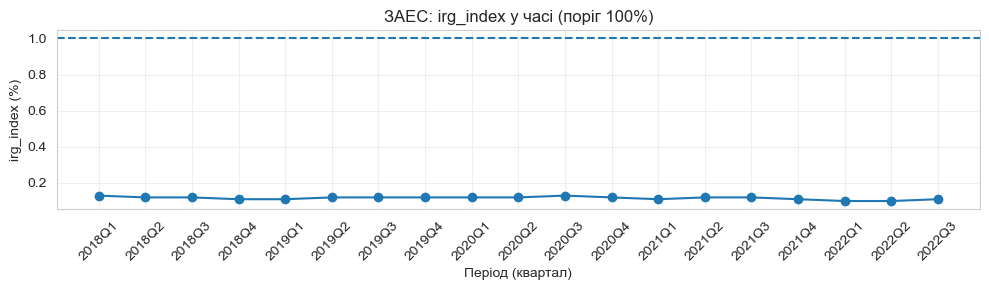

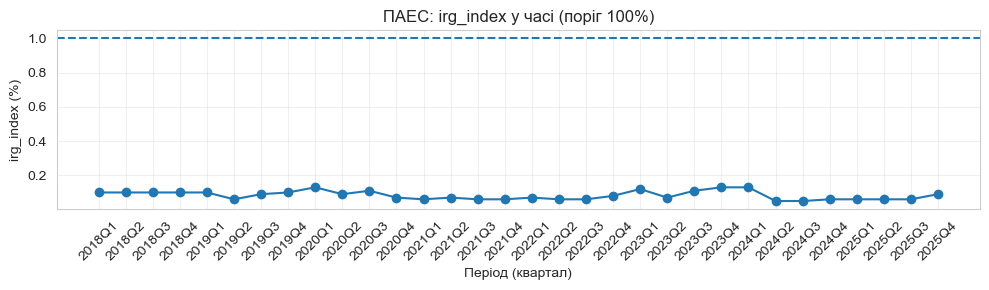

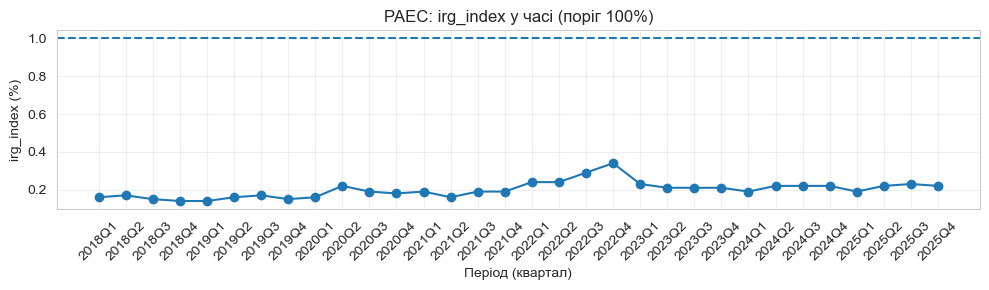

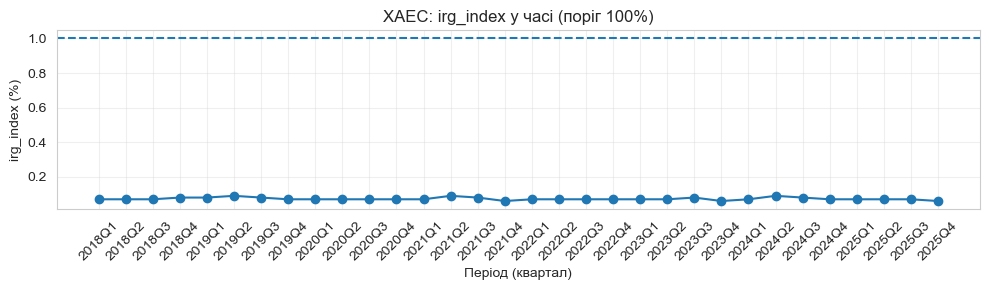

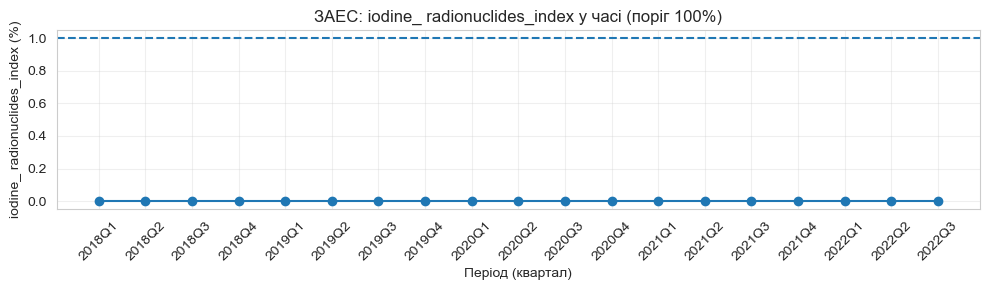

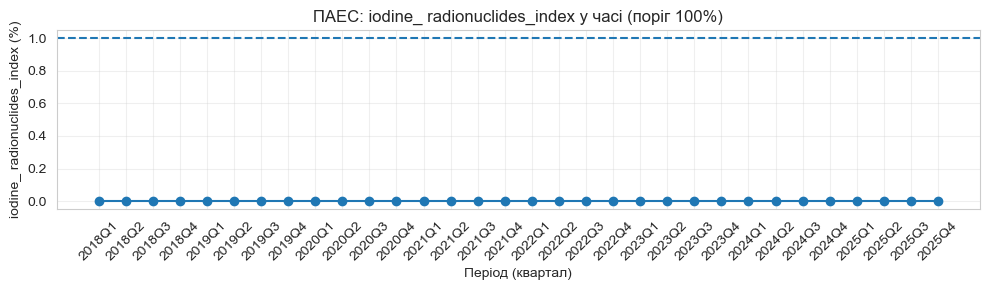

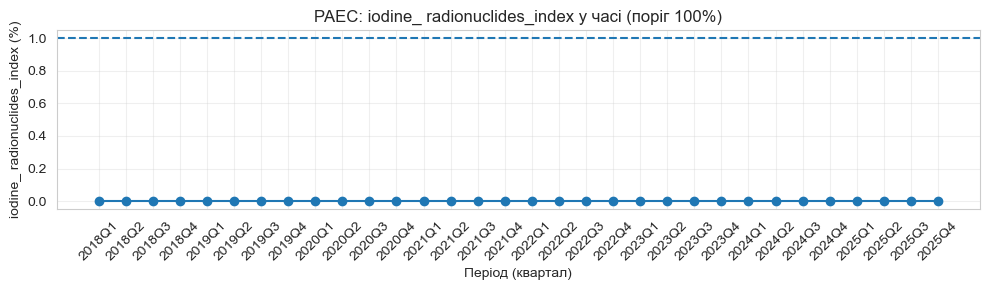

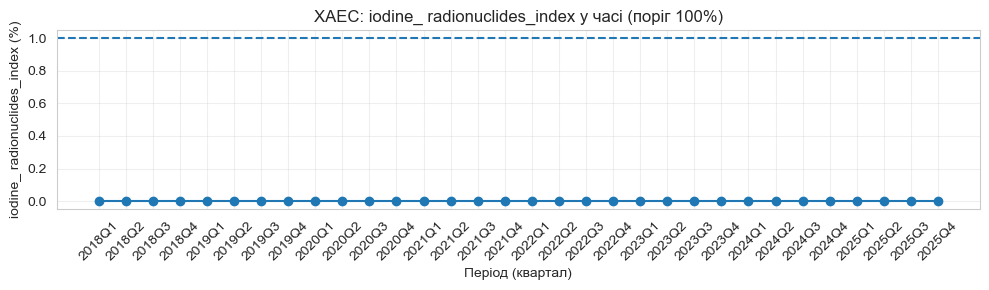

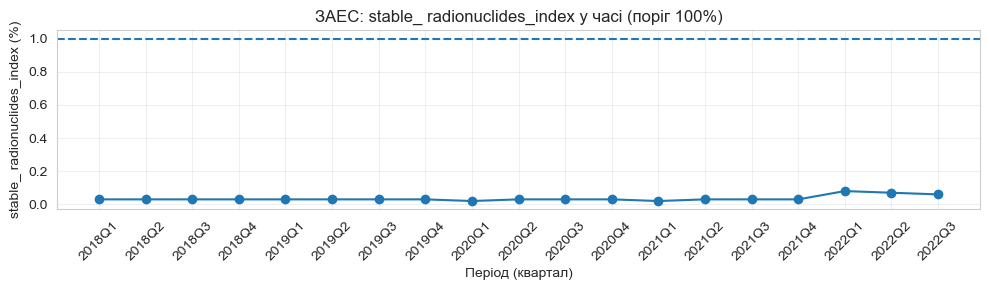

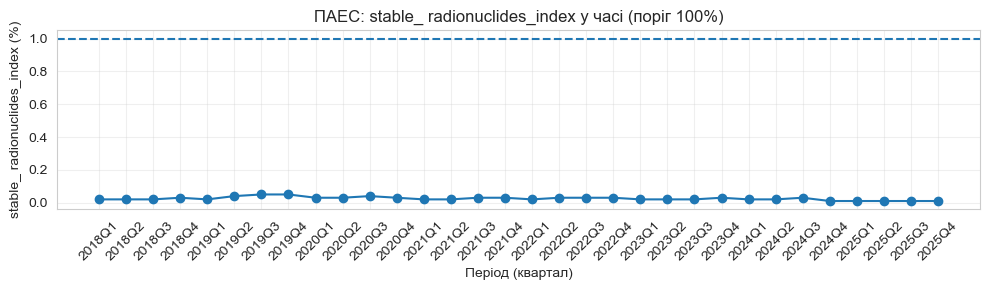

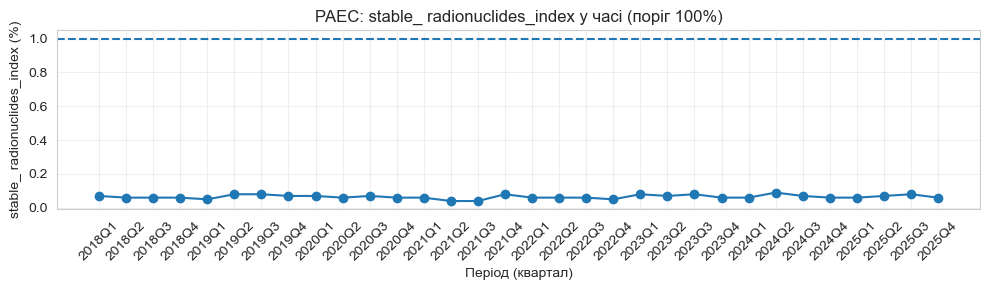

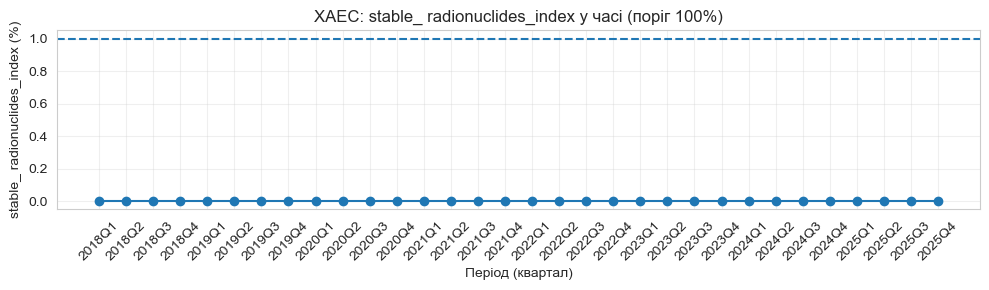

In [41]:
LIMIT = 1

if "period" not in df.columns:
    df["period"] = pd.PeriodIndex.from_fields(year=df["year"], quarter=df["quarter"], freq="Q")

stations = df["station"].dropna().unique()

for col in check_indices:
    for st in stations:
        d = df[df["station"] == st].sort_values("period")
        if d[col].dropna().empty:
            continue

        plt.figure(figsize=(10,3))
        plt.plot(d["period"].astype(str), d[col], marker="o")
        plt.axhline(LIMIT, linestyle="--")
        plt.title(f"{st}: {col} у часі (поріг 100%)")
        plt.xticks(rotation=45)
        plt.xlabel("Період (квартал)")
        plt.ylabel(f"{col} (%)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



## Гіпотеза №2

Перевіримо гіпотезу №2: об’єми радіоактивних викидів можуть демонструвати сезонні коливання, пов’язані з опалювальним періодом або плановими ремонтними роботами.

In [46]:
summary_q = (
    df.groupby("quarter")["index_radioactive_releas"]
      .agg(["mean","min","max"])
      .reset_index()
)
print(summary_q)

   quarter      mean    min    max
0        1  0.906655  0.070  3.850
1        2  1.030586  0.115  4.967
2        3  1.162241  0.110  4.901
3        4  1.080679  0.070  4.529


Було проаналізовано середні значення показника index_radioactive_release за кварталами. Середні значення змінюються від 0.91 у 1 кварталі до 1.16 у 3 кварталі. У 2 та 4 кварталах середні показники становлять 1.03 та 1.08.

Таким чином, простежується чітка тенденція зростання показника до 3 кварталу з подальшою стабілізацією, що свідчить про наявність сезонних коливань. Отже, гіпотеза про можливі сезонні зміни обсягів радіоактивних викидів знаходить підтвердження.

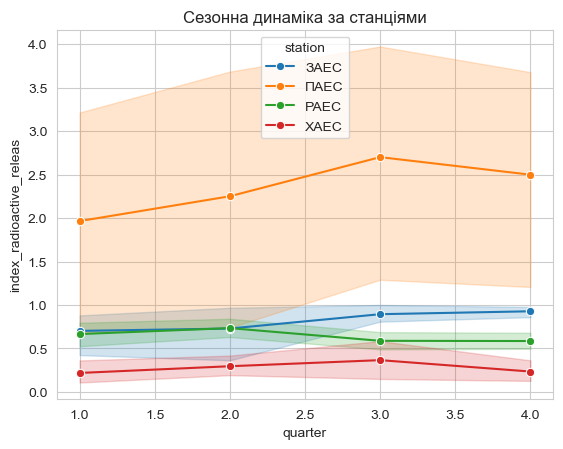

In [49]:
sns.lineplot(data=df, x='quarter', y='index_radioactive_releas', hue='station', marker='o')
plt.title("Сезонна динаміка за станціями")
plt.show()

## Гіпотеза №3

Перевіряємо гіпотезу №3: між показниками cs_137_emission та co_60_emission може існувати позитивна кореляція, що дозволяє припустити можливість прогнозування зміни одного радіонукліду на основі динаміки іншого.

In [19]:
df.head()

,year,quarter,station,irg,irg_index,iodine_ radionuclides,iodine_ radionuclides_index,stable_radionuclides,stable_ radionuclides_index,cs_137_emission,co_60_ emission,cs_137_dump,co_60_dump,volume,index_radioactive_releas,index_dump,period
0,2018,1,ЗАЕС,89.0,0.13,260.0,0.0,650.0,0.03,1980.0,1020.0,4330.0,3670.0,833000.0,0.149,0.33,2018Q1
1,2018,2,ЗАЕС,84.0,0.12,262.0,0.0,640.0,0.03,453.0,1003.0,4627.0,3432.0,812667.0,0.115,0.91,2018Q2
2,2018,3,ЗАЕС,84.0,0.12,235.0,0.0,611.0,0.03,876.0,201.0,5890.0,3500.0,874528.0,0.870,1.52,2018Q3
3,2018,4,ЗАЕС,79.0,0.11,240.0,0.0,750.0,0.03,304.0,868.0,3600.0,3100.0,778103.0,0.940,2.14,2018Q4
4,2019,1,ЗАЕС,78.0,0.11,265.0,0.0,697.0,0.03,1652.0,944.0,3608.0,3739.0,702304.0,0.830,0.39,2019Q1


Кореляційний аналіз нуклідів
Коефіцієнт кореляції між Cs-137 та Co-60: 0.269


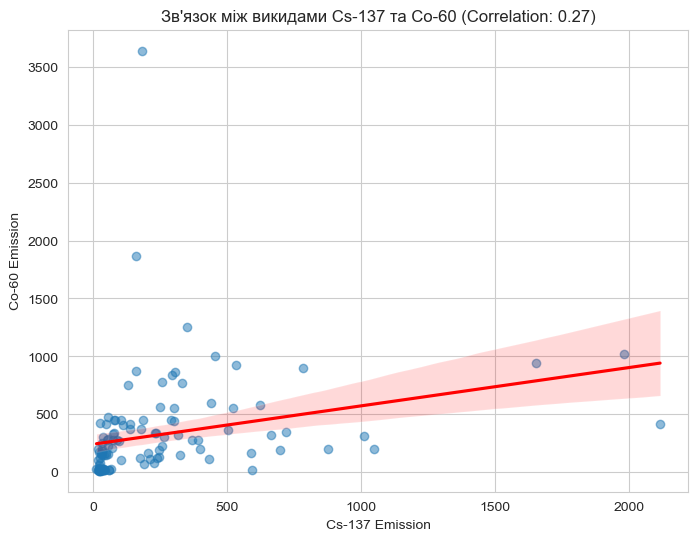

In [50]:
print("Кореляційний аналіз нуклідів")

correlation = df['cs_137_emission'].corr(df['co_60_ emission'])
print(f"Коефіцієнт кореляції між Cs-137 та Co-60: {correlation:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='cs_137_emission', y='co_60_ emission', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f"Зв'язок між викидами Cs-137 та Co-60 (Correlation: {correlation:.2f})")
plt.xlabel("Cs-137 Emission")
plt.ylabel("Co-60 Emission")
plt.show()

Було проведено кореляційний аналіз між показниками cs_137_emission та co_60_emission. Отримане значення коефіцієнта кореляції становить r = 0.27.

Це свідчить про наявність слабкого позитивного зв’язку між обсягами викидів Cs-137 та Co-60. Тобто зі зростанням викидів Cs-137 спостерігається тенденція до зростання викидів Co-60, проте сила зв’язку є невисокою.

Початкова гіпотеза про можливість прогнозування одного показника на основі іншого за рахунок сильної позитивної кореляції не підтвердилася. Зв'язок занадто слабкий для побудови надійних прогностичних моделей.